In [1]:
import pandas as pd
import allel
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
cam5_annot = pd.read_csv('cam5_annot.csv')

In [3]:
clim1001 = pd.read_csv('../key_files/1001g_regmap_grenet_ecotype_info_corrected_bioclim_2024May16.csv')

clim1001['ecotypeid'] = clim1001['ecotypeid'].astype(str)

In [4]:
ecotypeid_to_bio1 = clim1001.set_index('ecotypeid')['bio1'].to_dict()

In [9]:
import subprocess

command = """
grep "^#" ../gwas/1001g/1001g_grenet_climate.recode.vcf > filtered_cam5_1001g.vcf && \
grep "^2\s" ../gwas/1001g/1001g_grenet_climate.recode.vcf | \
awk '$2 >= 11531967 && $2 <= 11534358' >> filtered_cam5_1001g.vcf
"""

# Run the command in a bash shell
subprocess.run(command, shell=True, executable='/bin/bash')

CompletedProcess(args='\ngrep "^#" ../gwas/1001g/1001g_grenet_climate.recode.vcf > filtered_cam5_1001g.vcf && grep "^2\\s" ../gwas/1001g/1001g_grenet_climate.recode.vcf | awk \'$2 >= 11531967 && $2 <= 11534358\' >> filtered_cam5_1001g.vcf\n', returncode=0)

In [ ]:
command = """
zgrep "^#" ../gwas/greneNet_final_v1.1.recode.vcf.gz> filtered_cam5_grenenet.vcf && \
zgrep "^2\s" ../gwas/greneNet_final_v1.1.recode.vcf.gz | \
awk '$2 >= 11531967 && $2 <= 11534358' >> filtered_cam5_grenenet.vcf
"""

# Run the command in a bash shell
subprocess.run(command, shell=True, executable='/bin/bash')

In [6]:
exons_utr_df = pd.read_csv('cam5_exons_utr.csv')

In [7]:
# Convert start and end into an IntervalIndex
exons_utr_df['interval'] = pd.IntervalIndex.from_arrays(exons_utr_df['start'], exons_utr_df['end'], closed='both')

# Set the IntervalIndex as the index of the DataFrame
exons_utr_df.set_index('interval', inplace=True)

In [31]:
vcf1001 = allel.read_vcf('filtered_cam5_1001g.vcf')

geno = vcf1001['calldata/GT']

geno = geno.sum(axis=2)

geno = pd.DataFrame(geno)

geno.columns = vcf1001['samples']

g1001_chrom_pos = pd.DataFrame({'chrom': vcf1001['variants/CHROM'], 'pos': vcf1001['variants/POS']})

vcf1001 = pd.concat([g1001_chrom_pos, geno],axis=1)

In [32]:
vcf_1001_cam5annot = cam5_annot.merge(vcf1001, on = 'pos')

vcf_1001_cam5annot = vcf_1001_cam5annot.drop('chrom_x',axis=1)

bios_maped = vcf_1001_cam5annot.columns[5:].map(ecotypeid_to_bio1)

new_columns = ['pos', 'EFF', 'LOF', 'NMD', 'chrom_y'] + bios_maped.tolist()

vcf_1001_cam5annot.columns = new_columns

eff_columns = vcf_1001_cam5annot['EFF'].str.split('|', expand=True)

eff_columns.columns = ['Effect', 'Impact', 'Position', 'Change', 'Gene', 'Biotype', 'Rank', 'HGVS.c', 'HGVS.p', 'cdna_pos', 'Other']

eff_columns = eff_columns.drop(['Position', 'Change', 'Gene', 'Biotype', 'cdna_pos', 'Other'],axis=1)

vcf_1001_cam5annot = pd.concat([eff_columns, vcf_1001_cam5annot],axis=1)





In [33]:
vcf_1001_cam5annot.loc[(vcf_1001_cam5annot['pos']>= 11533904) & (vcf_1001_cam5annot['pos']<= 11534263), 'block'] = 'sign_block'

In [34]:
vcf_1001_cam5annot[(vcf_1001_cam5annot['pos']>= 11532004) & (vcf_1001_cam5annot['pos']<= 11532068)]

,Effect,Impact,Rank,HGVS.c,HGVS.p,pos,EFF,LOF,NMD,chrom_y,...,8.88749980926514,8.21666622161865,9.11666679382324,15.8291664123535,15.1000003814697,18.3333339691162,13.2791662216187,8.71666717529297,9.88749980926514,block
0,5_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.1,11532055,5_prime_UTR_variant(MODIFIER||14|c.-14A>C|149|...,NaN,NaN,2,...,0,0,0,0,0,0,0,0,0,NaN


In [35]:


exons_utr_df_var1 = exons_utr_df[exons_utr_df['annotation'] == 'Parent=AT2G27030.1']
# Map each SNP position to its corresponding feature type
vcf_1001_cam5annot['feature_type_var1'] = vcf_1001_cam5annot['pos'].apply(
    lambda x: exons_utr_df_var1.loc[exons_utr_df_var1.index.contains(x)]['feature_type'].values[0] if any(exons_utr_df_var1.index.contains(x)) else 'intergenic'
)

exons_utr_df_var2 = exons_utr_df[exons_utr_df['annotation'] == 'Parent=AT2G27030.2']
# Map each SNP position to its corresponding feature type
vcf_1001_cam5annot['feature_type_var2'] = vcf_1001_cam5annot['pos'].apply(
    lambda x: exons_utr_df_var2.loc[exons_utr_df_var2.index.contains(x)]['feature_type'].values[0] if any(exons_utr_df_var2.index.contains(x)) else 'intergenic'
)

exons_utr_df_var3 = exons_utr_df[exons_utr_df['annotation'] == 'Parent=AT2G27030.3']
# Map each SNP position to its corresponding feature type
vcf_1001_cam5annot['feature_type_var3'] = vcf_1001_cam5annot['pos'].apply(
    lambda x: exons_utr_df_var3.loc[exons_utr_df_var3.index.contains(x)]['feature_type'].values[0] if any(exons_utr_df_var3.index.contains(x)) else 'intergenic'
)

# Display the updated DataFrame


In [36]:
vcf_1001_cam5annot.columns

Index([           'Effect',            'Impact',              'Rank',
                  'HGVS.c',            'HGVS.p',               'pos',
                     'EFF',               'LOF',               'NMD',
                 'chrom_y',
       ...
          15.8291664123535,    15.1000003814697,    18.3333339691162,
          13.2791662216187,    8.71666717529297,    9.88749980926514,
                   'block', 'feature_type_var1', 'feature_type_var2',
       'feature_type_var3'],
      dtype='object', length=1151)

In [37]:
vcf_1001_cam5annot['Effect'].unique()

array(['5_prime_UTR_variant(MODIFIER',
       '5_prime_UTR_premature_start_codon_gain_variant(LOW',
       'synonymous_variant(LOW', '3_prime_UTR_variant(MODIFIER',
       'missense_variant(MODERATE', 'upstream_gene_variant(MODIFIER'],
      dtype=object)

In [38]:
vcf_1001_cam5annot['Impact'].unique()

array(['', 'SILENT', 'MISSENSE'], dtype=object)

In [39]:
vcf_1001_cam5annot[vcf_1001_cam5annot['Impact'] != '']

,Effect,Impact,Rank,HGVS.c,HGVS.p,pos,EFF,LOF,NMD,chrom_y,...,15.8291664123535,15.1000003814697,18.3333339691162,13.2791662216187,8.71666717529297,9.88749980926514,block,feature_type_var1,feature_type_var2,feature_type_var3
42,synonymous_variant(LOW,SILENT,protein_coding,CODING,AT2G27030.2,11532790,synonymous_variant(LOW|SILENT|ggT/ggG|p.Gly24G...,NaN,NaN,2,...,0,2,0,0,0,0,NaN,exon,exon,exon
43,synonymous_variant(LOW,SILENT,protein_coding,CODING,AT2G27030.2,11532868,synonymous_variant(LOW|SILENT|ctC/ctG|p.Leu50L...,NaN,NaN,2,...,0,0,2,0,2,0,NaN,exon,exon,exon
44,synonymous_variant(LOW,SILENT,protein_coding,CODING,AT2G27030.2,11532919,synonymous_variant(LOW|SILENT|gcA/gcT|p.Ala67A...,NaN,NaN,2,...,2,0,0,0,2,0,NaN,exon,exon,exon
76,synonymous_variant(LOW,SILENT,protein_coding,CODING,AT2G27030.3,11534092,synonymous_variant(LOW|SILENT|agA/agG|p.Arg154...,NaN,NaN,2,...,0,0,0,0,0,0,sign_block,intergenic,exon,exon
77,missense_variant(MODERATE,MISSENSE,protein_coding,CODING,AT2G27030.3,11534094,missense_variant(MODERATE|MISSENSE|gTt/gCt|p.V...,NaN,NaN,2,...,2,0,0,2,2,0,sign_block,intergenic,exon,exon
78,missense_variant(MODERATE,MISSENSE,protein_coding,CODING,AT2G27030.3,11534099,missense_variant(MODERATE|MISSENSE|Gca/Aca|p.A...,NaN,NaN,2,...,2,0,0,2,2,0,sign_block,intergenic,exon,exon
79,missense_variant(MODERATE,MISSENSE,protein_coding,CODING,AT2G27030.3,11534102,missense_variant(MODERATE|MISSENSE|Gca/Aca|p.A...,NaN,NaN,2,...,2,0,0,2,2,0,sign_block,intergenic,exon,exon
80,synonymous_variant(LOW,SILENT,protein_coding,CODING,AT2G27030.3,11534143,synonymous_variant(LOW|SILENT|aaT/aaC|p.Asn171...,NaN,NaN,2,...,2,0,0,2,2,0,sign_block,intergenic,exon,exon
81,synonymous_variant(LOW,SILENT,protein_coding,CODING,AT2G27030.3,11534161,synonymous_variant(LOW|SILENT|caC/caT|p.His177...,NaN,NaN,2,...,0,0,0,0,0,0,sign_block,intergenic,exon,exon
82,missense_variant(MODERATE,MISSENSE,protein_coding,CODING,AT2G27030.3,11534165,missense_variant(MODERATE|MISSENSE|Cgt/Tgt|p.A...,NaN,NaN,2,...,2,0,0,2,2,0,sign_block,intergenic,exon,exon


In [21]:
vcf_1001_cam5annot = vcf_1001_cam5annot[vcf_1001_cam5annot['block'] == 'sign_block']

In [22]:
for_hm

NameError: name 'for_hm' is not defined

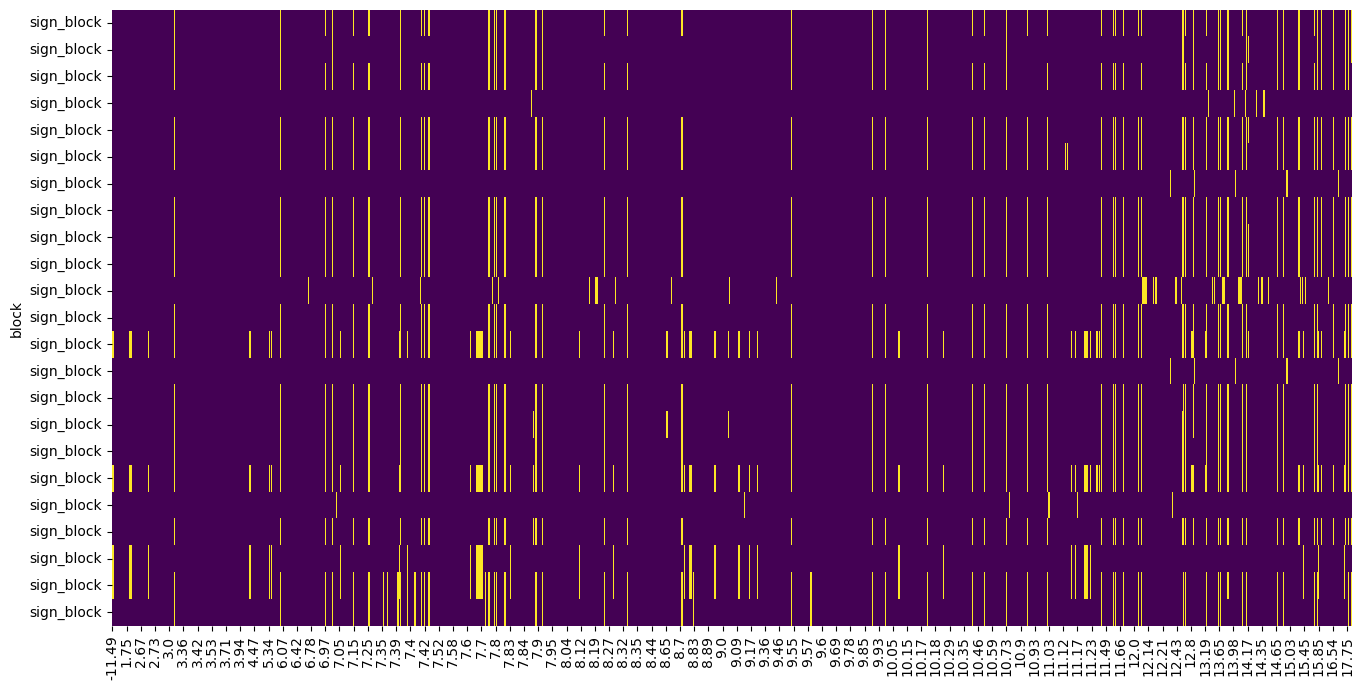

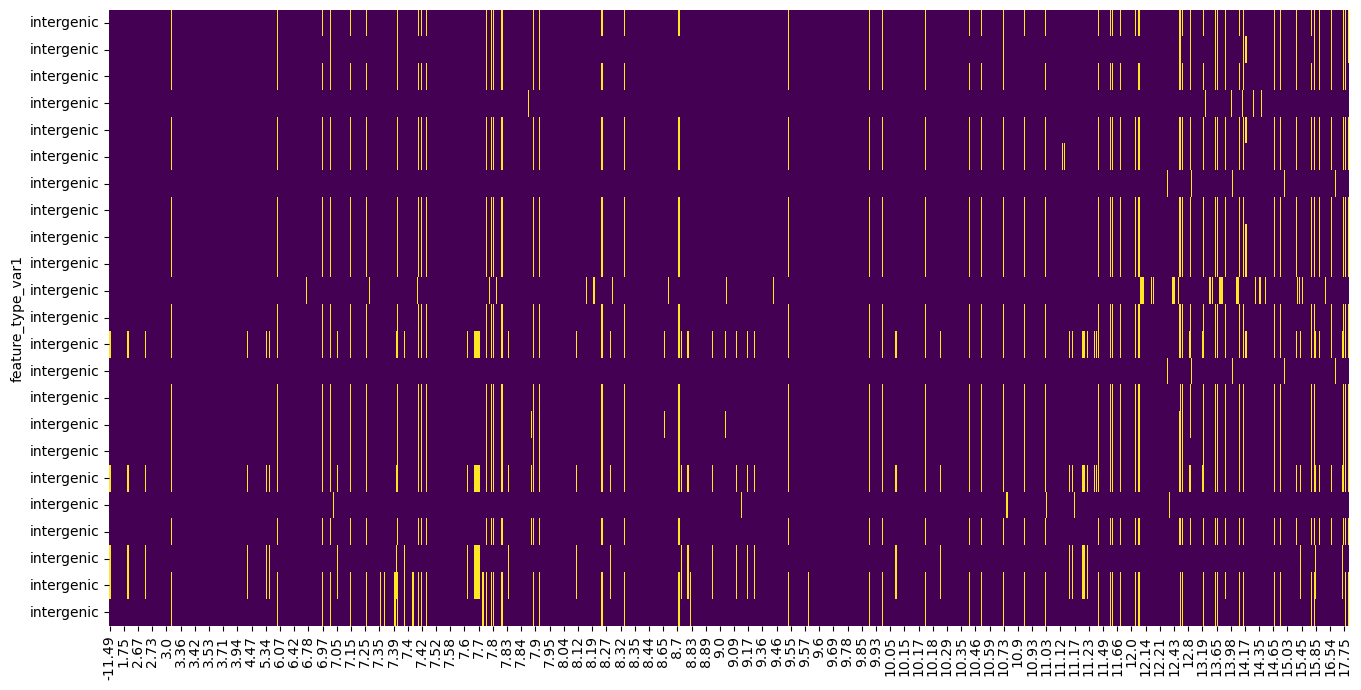

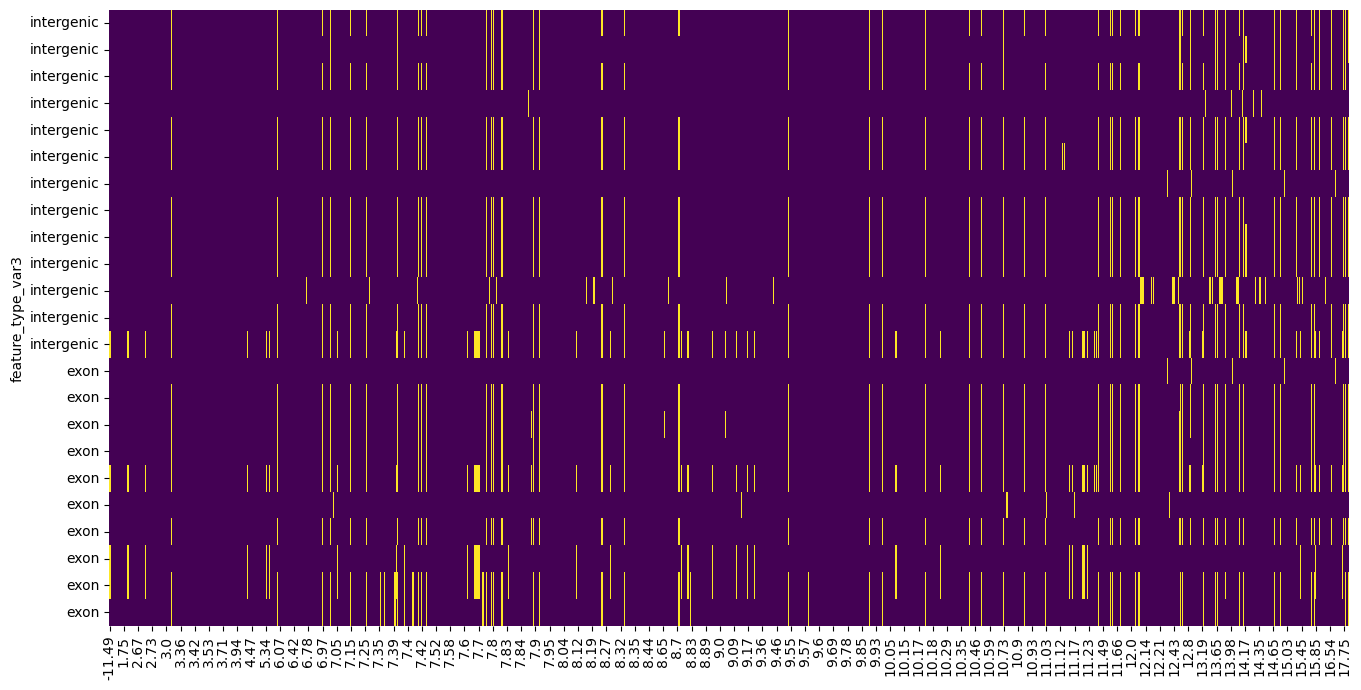

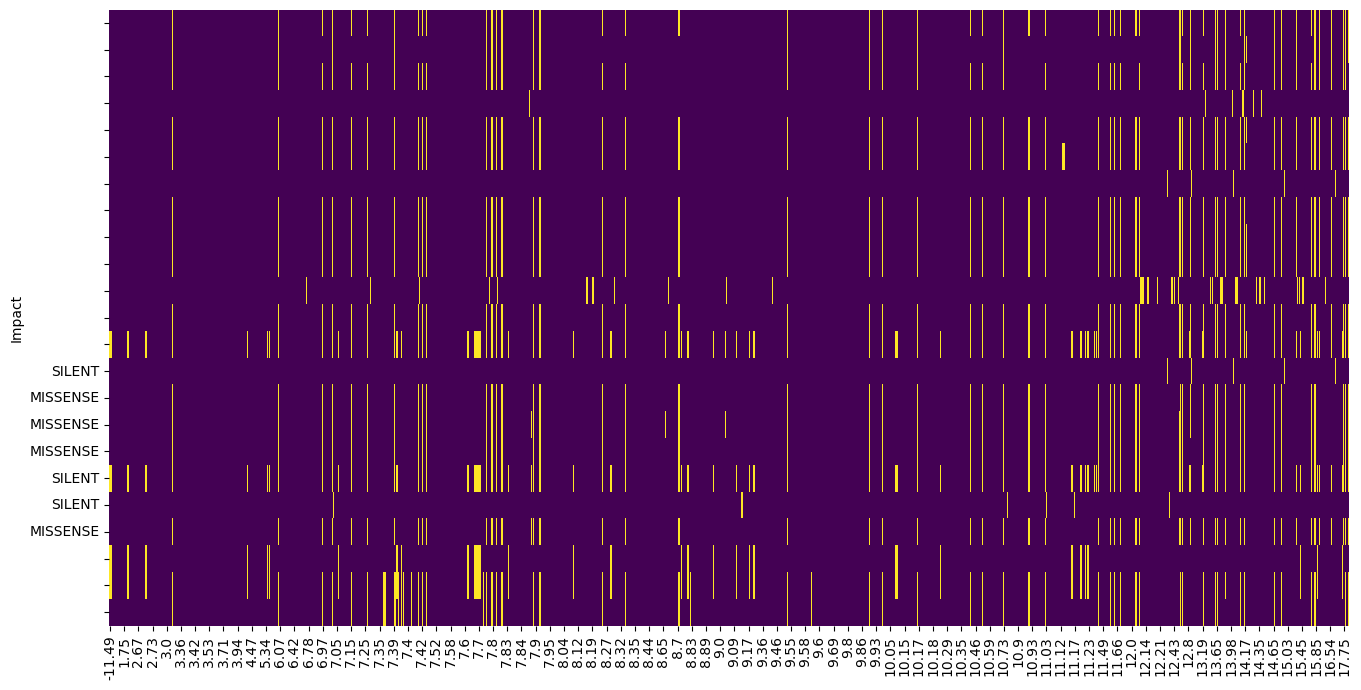

In [253]:
for i in [ 'block', 'feature_type_var1', 'feature_type_var3', 'Impact', ]:  # 'LOF',  'NMD''EFF',  'pos', 'HGVS.c',  'HGVS.p',  'Rank',  'feature_type_var2' 'Effect'
    for_hm = vcf_1001_cam5annot.copy()
    for_hm = for_hm.set_index(i)

    for_hm = for_hm.iloc[:, 10:-4]
    
    for_hm = for_hm.T
    
    for_hm = for_hm.sort_index()
    
    for_hm.index = np.round(for_hm.index.astype(float),2)

    for_hm = for_hm.T

    # Create the heatmap
    plt.figure(figsize=(16, 8))  # Increase the figure size to make the heatmap bigger
    heatmap_plot = sns.heatmap(for_hm, cmap="viridis", cbar=False)
    #plt.savefig(f'heaatmap_1001_g__block{i}.png')
    # Show the plot
    plt.show()

In [235]:
for_hm.

,-11.49,-11.49,-4.28,-3.27,-3.00,-2.87,-2.49,-1.93,-1.18,0.72,...,17.15,17.17,17.18,17.23,17.70,17.75,17.84,18.33,18.59,22.70
Impact,,,,,,,,,,,,,,,,,,,,,
,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
,0,0,2,0,0,0,2,0,0,0,...,0,2,2,0,0,0,0,0,2,2
,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,2,2,0,0,0,0,0,0,0,0,...,0,0,0,2,0,0,0,0,0,0
,2,2,0,0,0,0,0,0,0,0,...,0,0,0,2,0,0,2,0,0,2
,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,2


In [24]:
indexes = ['block', 'feature_type_var1', 'feature_type_var3', 'Impact']
for_hm = vcf_1001_cam5annot.set_index(indexes)

In [25]:
for_hm = for_hm.iloc[:, 9:-1].T 

In [40]:
indexes = ['block', 'feature_type_var1', 'feature_type_var3', 'Impact']
for_hm = vcf_1001_cam5annot.set_index(indexes)

# Slice and transpose the DataFrame
for_hm = for_hm.iloc[:, 9:-1].T

In [41]:
import numpy as np

In [42]:
# Round the index values
for_hm.index = np.round(for_hm.index.astype(float), 2)

In [43]:
for_hm = for_hm.T

In [44]:
for_hm

9.17   8.88   10.36  \
block      feature_type_var1 feature_type_var3 Impact                        
NaN        exon              exon                          0      0      0   
           intergenic        intergenic                    2      2      2   
                                                           0      0      0   
                                                           0      0      2   
                                                           0      0      0   
...                                                      ...    ...    ...   
sign_block intergenic        exon                          0      0      0   
                                                           0      0      0   
                                                           0      0      0   
NaN        intergenic        exon                          0      0      0   
                             intergenic                    0      0      0   

                                                       9.87   11.32  2.70   \
block      feature_type_var1 feature_type_var3 Impact                        
NaN        exon              exon                          2      0      0   
           intergenic        intergenic                    2      2      0   
                                                           0      0      0   
                                                           0      0      0   
                                                           0      0      0   
...                                                      ...    ...    ...   
sign_block intergenic        exon                          0      0      0   
                                                           0      0      0   
                                                           0      0      0   
NaN        intergenic        exon                          0      0      0   
                             intergenic                    2      0      0   

                                                       2.70   2.70   7.70   \
block      feature_type_var1 feature_type_var3 Impact                        
NaN        exon              exon                          0      0      0   
           intergenic        intergenic                    0      0      0   
                                                           0      0      0   
                                                           0      0      0   
                                                           0      0      0   
...                                                      ...    ...    ...   
sign_block intergenic        exon                          0      2      2   
                                                           0      2      2   
                                                           0      0      0   
NaN        intergenic        exon                          0      0      0   
                             intergenic                    0      0      0   

                                                       13.72  ...  8.29   \
block      feature_type_var1 feature_type_var3 Impact         ...          
NaN        exon              exon                          0  ...      0   
           intergenic        intergenic                    0  ...      2   
                                                           0  ...      0   
                                                           0  ...      0   
                                                           0  ...      0   
...                                                      ...  ...    ...   
sign_block intergenic        exon                          0  ...      0   
                                                           0  ...      0   
                                                           0  ...      0   
NaN        intergenic        exon                          0  ...      0   
                             intergenic                    0  ...      0   

                     

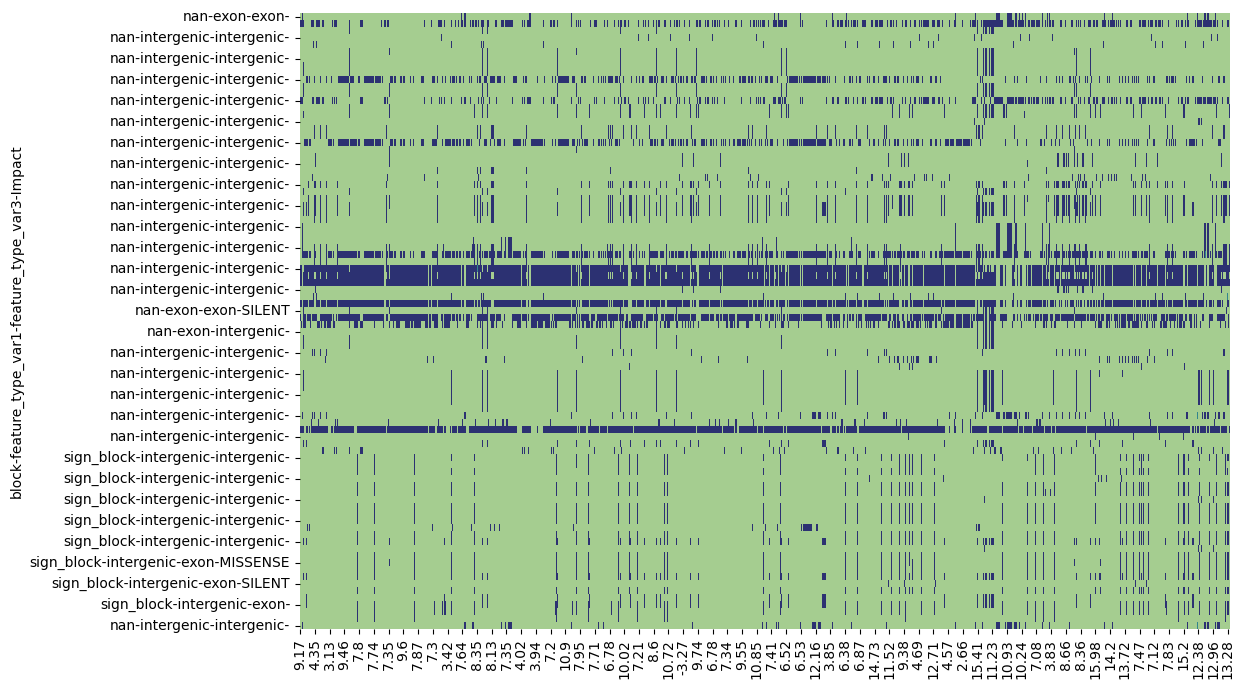

In [47]:
plt.figure(figsize=(12, 8))  # Increase the figure size to make the heatmap bigger
heatmap_plot = sns.heatmap(for_hm, cmap="crest", cbar=False)
plt.savefig('heatmap_cam5_region.png')
# Show the plot
plt.show()

In [258]:
vcfgrene = allel.read_vcf('filtered_cam5_grenenet.vcf')

geno = vcfgrene['calldata/GT']

geno = geno.sum(axis=2)

geno = pd.DataFrame(geno)

geno.columns = vcfgrene['samples']

grene_chrom_pos = pd.DataFrame({'chrom': vcfgrene['variants/CHROM'], 'pos': vcfgrene['variants/POS']})

vcfgrene = pd.concat([grene_chrom_pos, geno],axis=1)

In [259]:
vcf_grene_cam5annot = cam5_annot.merge(vcfgrene, on = 'pos')

vcf_grene_cam5annot = vcf_grene_cam5annot.drop('chrom_x',axis=1)

bios_maped = vcf_grene_cam5annot.columns[5:].map(ecotypeid_to_bio1)

new_columns = ['pos', 'EFF', 'LOF', 'NMD', 'chrom_y'] + bios_maped.tolist()

vcf_grene_cam5annot.columns = new_columns

eff_columns = vcf_grene_cam5annot['EFF'].str.split('|', expand=True)

eff_columns.columns = ['Effect', 'Impact', 'Position', 'Change', 'Gene', 'Biotype', 'Rank', 'HGVS.c', 'HGVS.p', 'cdna_pos', 'Other']

eff_columns = eff_columns.drop(['Position', 'Change', 'Gene', 'Biotype', 'cdna_pos', 'Other'],axis=1)

vcf_grene_cam5annot = pd.concat([eff_columns, vcf_grene_cam5annot],axis=1)





In [260]:
vcf_grene_cam5annot

,Effect,Impact,Rank,HGVS.c,HGVS.p,pos,EFF,LOF,NMD,chrom_y,...,14.0249996185303,13.8125,8.71666717529297,8.38749980926514,15.8291664123535,15.1000003814697,18.3333339691162,13.2791662216187,8.71666717529297,9.88749980926514
0,5_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.1,11532055,5_prime_UTR_variant(MODIFIER||14|c.-14A>C|149|...,NaN,NaN,2,...,0,0,0,2,0,0,0,0,0,0
1,5_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.2,11532148,5_prime_UTR_variant(MODIFIER||571|c.-571C>A|11...,NaN,NaN,2,...,2,2,2,2,0,0,0,2,0,0
2,5_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.2,11532152,5_prime_UTR_variant(MODIFIER||567|c.-567T>C|11...,NaN,NaN,2,...,0,0,0,0,0,0,0,0,0,0
3,5_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.2,11532162,5_prime_UTR_variant(MODIFIER||557|c.-557C>T|11...,NaN,NaN,2,...,0,0,0,0,0,0,0,2,0,0
4,5_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.2,11532176,5_prime_UTR_variant(MODIFIER||543|c.-543A>G|11...,NaN,NaN,2,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,3_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.2,11534224,3_prime_UTR_variant(MODIFIER||1164|c.*1164C>T|...,NaN,NaN,2,...,0,0,0,0,0,0,0,0,0,0
84,3_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.2,11534244,3_prime_UTR_variant(MODIFIER||1184|c.*1184T>A|...,NaN,NaN,2,...,0,0,2,0,2,0,0,0,0,0
85,3_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.2,11534263,3_prime_UTR_variant(MODIFIER||1203|c.*1203T>C|...,NaN,NaN,2,...,0,0,2,0,2,0,0,2,0,0
86,3_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.3,11534313,3_prime_UTR_variant(MODIFIER||137|c.*137T>G|18...,NaN,NaN,2,...,0,0,0,0,2,0,0,0,0,0


In [ ]:
for_hm = vcf_grene_cam5annot.set_index('Impact')

In [256]:
for_hm = for_hm.drop(for_hm.columns[:9],axis=1).T

for_hm = for_hm.sort_index()


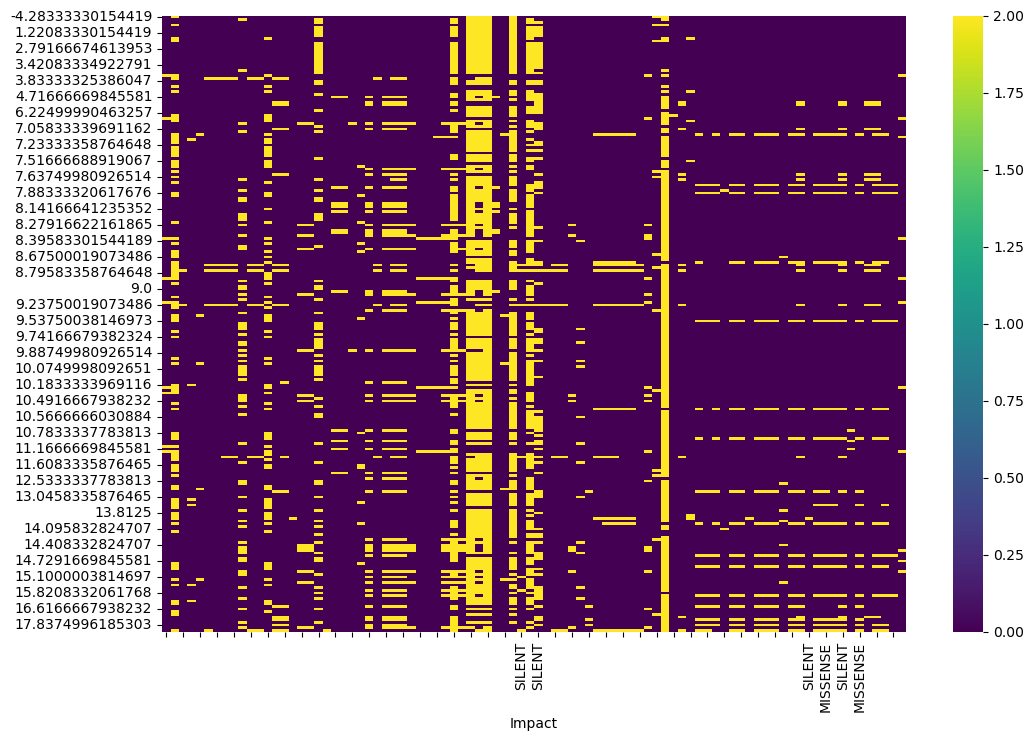

In [257]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming `for_hm` is the dataframe you want to plot
plt.figure(figsize=(12, 8))  # Increase the figure size to make the heatmap bigger
sns.heatmap(for_hm, cmap="viridis")
plt.show()

In [6]:
samples = pd.read_csv('../key_files/merged_sample_table.csv')[['site', 'plot', 'generation', 'total_flower_counts']]

samples = samples.groupby(['site', 'plot', 'generation'])['total_flower_counts'].sum().reset_index()

samples['min_perc'] = 1/samples['total_flower_counts']

samples['code'] = samples['site'].astype(str) + '_'  + samples['generation'].astype(str) + '_' + samples['plot'].astype(str) 

ecotype_freq = pd.read_csv('../key_files/delta_ecotype_freq.txt',sep = '\t')

climate = pd.read_csv('../key_files/bioclimvars_experimental_sites_era5.csv')[['site', 'bio1']]

In [7]:
ecotype_freq

,1_1_1,1_1_2,1_1_3,1_1_4,1_1_5,1_1_6,1_1_7,1_1_8,1_1_9,1_1_10,...,60_1_3,60_1_4,60_1_5,60_1_6,60_1_7,60_1_8,60_1_9,60_1_10,60_1_11,60_1_12
0,-0.004779,-0.003618,-0.004384,-0.004367,-0.003516,-0.003465,-0.002892,-0.003213,-0.003949,-0.003536,...,-0.002931,-0.006334,-0.005966,-0.006406,-0.004394,-0.004535,-0.005999,-0.005784,-0.006148,-0.002948
1,-0.002672,-0.002692,0.004330,-0.002449,-0.002474,-0.002409,-0.002703,-0.002497,-0.002316,0.006181,...,-0.002969,0.035715,-0.003485,-0.003318,-0.003485,-0.002687,-0.001908,-0.002737,-0.003331,-0.003245
2,-0.001783,-0.002597,-0.002392,0.000685,-0.002393,-0.002487,-0.002388,-0.002254,-0.002193,-0.002222,...,-0.002947,-0.002815,-0.003033,-0.002696,-0.002730,-0.002974,-0.002972,-0.002395,-0.003077,-0.002918
3,-0.003439,-0.003167,-0.003294,-0.002949,-0.000956,-0.003314,-0.002798,-0.003107,-0.003227,-0.002876,...,-0.003534,-0.003873,-0.004004,-0.003849,-0.003966,-0.002065,-0.002800,-0.003361,-0.003743,-0.003851
4,-0.003732,-0.000501,-0.003599,-0.003183,0.016787,-0.003634,-0.002911,-0.003327,-0.003423,-0.003125,...,-0.003657,-0.003903,-0.004191,-0.004147,-0.003959,0.010703,-0.002833,-0.003927,-0.003933,-0.004000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,-0.000962,0.004074,-0.000991,0.000051,-0.000095,0.002813,0.002104,0.007236,0.001439,0.003409,...,-0.001014,-0.001117,-0.001234,-0.000819,-0.000961,0.002043,0.012923,-0.000378,0.000292,-0.001235
227,-0.000994,0.003050,-0.000515,0.000043,-0.000360,0.000012,0.000284,0.004954,-0.001064,-0.000854,...,-0.001474,-0.002874,-0.002784,-0.002976,-0.001884,0.000191,-0.002476,-0.002588,-0.002929,-0.002558
228,-0.000815,-0.000616,-0.000788,-0.000691,-0.000701,0.000035,-0.000778,0.000026,-0.000447,0.000575,...,-0.000946,-0.000996,-0.001157,0.018520,-0.001046,-0.000827,-0.000107,-0.000898,-0.000992,-0.000860
229,-0.001622,-0.001627,-0.001513,-0.001441,-0.001741,-0.001634,-0.001734,-0.001646,-0.001646,-0.001573,...,-0.001898,-0.001696,-0.002060,-0.001937,-0.002022,-0.001833,-0.001715,-0.001767,-0.002158,-0.001991


In [ ]:
grenenet_ecotypes = pd.read_csv('../key_files/founder_ecotype_frequency.txt', sep = '\t',header=None)[0]

ecotype_freq = ecotype_freq.set_index(grenenet_ecotypes)

ecotype_freq = ecotype_freq.T 
ecotype_freq = ecotype_freq.reset_index()
ecotype_freq['generation'] = ecotype_freq['index'].str.split('_').str[1]

ecotype_freq['plot'] = ecotype_freq['index'].str.split('_').str[2]

ecotype_freq['site'] = ecotype_freq['index'].str.split('_').str[0] 

ecotype_freq = ecotype_freq.drop('index', axis=1)

ecotype_freq = ecotype_freq.melt(id_vars = ['plot','site', 'generation'])

ecotype_freq.columns = ['plot','site', 'generation', 'ecotype', 'freq']

clim1001f = clim1001[['ecotypeid', 'bio1']]

In [14]:
#clim1001f = clim1001f[clim1001f['bio1'] > 13]

In [ ]:
clim1001f['ecotypeid'] = clim1001f['ecotypeid'].astype(int)

ecotype_freq = ecotype_freq.merge(clim1001f, left_on = 'ecotype', right_on = 'ecotypeid')

ecotype_freq['generation'] = ecotype_freq['generation'].astype(int)

result = ecotype_freq.copy()

In [20]:
result

,plot,site,generation,ecotype,freq,ecotypeid,bio1
0,1,1,1,10002,-0.004779,10002,8.879167
1,2,1,1,10002,-0.003618,10002,8.879167
2,3,1,1,10002,-0.004384,10002,8.879167
3,4,1,1,10002,-0.004367,10002,8.879167
4,5,1,1,10002,-0.003516,10002,8.879167
...,...,...,...,...,...,...,...
172090,8,60,1,9992,-0.001896,9992,9.887500
172091,9,60,1,9992,-0.001719,9992,9.887500
172092,10,60,1,9992,0.034705,9992,9.887500
172093,11,60,1,9992,-0.002191,9992,9.887500


In [21]:
#import os

In [22]:
#clim_sites_during_exp = pd.read_csv('/carnegie/nobackup/scratch/tbellagio/grene/data/bioclimvars_experimental_sites_era5.csv')

In [ ]:
clim_sites_during_exp = pd.read_csv('/carnegie/nobackup/scratch/tbellagio/grene/data/worldclim_sitesdata.csv')

clim_sites_during_exp = clim_sites_during_exp[['site', 'bio1']]

clim_sites_during_exp['site'] = clim_sites_during_exp['site'].astype(str)

result.columns = ['plot', 'site', 'generation', 'ecotype', 'freq', 'ecotypeid', 'bio1_ecotype']



result = result.merge(clim_sites_during_exp, on ='site')

result.columns = ['plot', 'site', 'generation', 'ecotype', 'freq', 'ecotypeid',
       'bio1_ecotype', 'bio1_exp']



result = result.drop('ecotypeid',axis=1)

In [32]:
result['bio1_exp'] = result['bio1_exp'].round(2)
result['bio1_ecotype'] = result['bio1_ecotype'].round(2)

In [34]:
bioexp_vs_bioecotype = result.pivot_table(index = 'bio1_exp', columns = 'bio1_ecotype', values= 'freq' , aggfunc = 'median')

In [35]:
bioexp_vs_bioecotype = bioexp_vs_bioecotype.sort_index() 

In [36]:
sorted_columns = sorted(bioexp_vs_bioecotype.columns)
bioexp_vs_bioecotype = bioexp_vs_bioecotype[sorted_columns]

In [37]:
clim1001f['bio1'] = clim1001f['bio1'].round(2)

/tmp/ipykernel_1207403/1059384320.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clim1001f['bio1'] = clim1001f['bio1'].round(2)


In [38]:
clim1001f['ecotype_bio1'] = clim1001f['ecotypeid'].astype(str) + '_' + clim1001f['bio1'].astype(str)

/tmp/ipykernel_1207403/2563707021.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clim1001f['ecotype_bio1'] = clim1001f['ecotypeid'].astype(str) + '_' + clim1001f['bio1'].astype(str)


In [39]:
clim1001f_dcit = clim1001f.set_index('bio1')['ecotype_bio1'].to_dict()

In [40]:
bioexp_vs_bioecotype.columns = bioexp_vs_bioecotype.columns.map(clim1001f_dcit)

In [41]:
clim_sites_during_exp['bio1'] = clim_sites_during_exp['bio1'].round(2)

In [42]:
clim_sites_during_exp['site_bio1'] = clim_sites_during_exp['site'].astype(str) + '_' + clim_sites_during_exp['bio1'].astype(str)

In [43]:
clim_sites_during_exp_dict = clim_sites_during_exp.set_index('bio1')['site_bio1'].to_dict()

In [44]:
bioexp_vs_bioecotype.index = bioexp_vs_bioecotype.index.map(clim_sites_during_exp_dict)

In [45]:
bioexp_vs_bioecotype = bioexp_vs_bioecotype.fillna(0)

In [46]:
bioexp_vs_bioecotype

bio1_ecotype,766_-4.28,7298_-3.27,763_-3.0,765_-2.49,9766_-1.93,768_0.72,9634_1.22,772_1.62,8354_1.88,9632_2.66,...,9879_16.59,9522_16.62,9726_17.17,9559_17.18,7067_17.23,7063_17.7,9657_17.75,9944_17.84,6939_18.33,6911_22.7
bio1_exp,,,,,,,,,,,,,,,,,,,,,
27_5.34,-0.004198,-0.004211,-0.004110,-0.003758,-0.004748,-0.004809,-0.004935,-0.004622,-0.003696,-0.003628,...,-0.004351,-0.003321,-0.004586,-0.004689,-0.004445,-0.001949,-0.002985,-0.005360,-0.003163,-0.003613
24_5.41,-0.002497,-0.003257,-0.002982,-0.002785,-0.002744,-0.003879,-0.003641,-0.001677,-0.002859,-0.002674,...,-0.004347,-0.003187,-0.004110,-0.004468,-0.004001,-0.001780,-0.002482,-0.005360,-0.001929,-0.003550
48_7.33,-0.002983,-0.003665,-0.003333,-0.002806,-0.003429,-0.003707,-0.004176,-0.003372,-0.003215,-0.002793,...,-0.004301,-0.003244,-0.004227,-0.004325,-0.004103,-0.001632,-0.002649,-0.005322,-0.001956,-0.003517
37_7.53,-0.002488,-0.002483,-0.002790,-0.001978,-0.002818,-0.003379,-0.003568,-0.002809,-0.002238,-0.002091,...,-0.004298,-0.002934,-0.003035,-0.004151,-0.003160,-0.001518,-0.001943,-0.005285,-0.001404,-0.003347
23_7.82,0.001235,-0.002397,0.000683,0.005931,0.000881,0.000775,0.005669,0.005460,-0.000409,0.000998,...,-0.004043,-0.000364,-0.000925,-0.003201,-0.002599,-0.001159,-0.001384,-0.005039,-0.001163,-0.003192
25_7.9,-0.003261,-0.002530,-0.003241,-0.003157,-0.004060,-0.004065,-0.004331,-0.003898,-0.002662,-0.002879,...,-0.004266,-0.002860,-0.003791,-0.004177,-0.003526,-0.001543,-0.002263,-0.005266,-0.001532,-0.003327
42_8.34,-0.004080,-0.003478,-0.003893,-0.003541,-0.004648,-0.004643,-0.004707,-0.004490,-0.003323,-0.003396,...,-0.003959,-0.002472,-0.003552,-0.003879,-0.004066,-0.001088,-0.002123,-0.004972,-0.001991,-0.003182
1_8.72,-0.003680,-0.001903,-0.003743,-0.003355,-0.004344,-0.004423,-0.004505,-0.004186,-0.003093,-0.003223,...,-0.003936,-0.002769,-0.003097,-0.003674,-0.002655,-0.001190,-0.001620,-0.005034,-0.001377,-0.003152
55_8.93,-0.004159,-0.003489,-0.004029,-0.003685,-0.004698,-0.004801,-0.004856,-0.004585,-0.003615,-0.003591,...,-0.004074,-0.001785,-0.003274,-0.003974,-0.004028,-0.001414,-0.001491,-0.005020,-0.002403,-0.003285


In [47]:
bioexp_vs_bioecotype

bio1_ecotype,766_-4.28,7298_-3.27,763_-3.0,765_-2.49,9766_-1.93,768_0.72,9634_1.22,772_1.62,8354_1.88,9632_2.66,...,9879_16.59,9522_16.62,9726_17.17,9559_17.18,7067_17.23,7063_17.7,9657_17.75,9944_17.84,6939_18.33,6911_22.7
bio1_exp,,,,,,,,,,,,,,,,,,,,,
27_5.34,-0.004198,-0.004211,-0.004110,-0.003758,-0.004748,-0.004809,-0.004935,-0.004622,-0.003696,-0.003628,...,-0.004351,-0.003321,-0.004586,-0.004689,-0.004445,-0.001949,-0.002985,-0.005360,-0.003163,-0.003613
24_5.41,-0.002497,-0.003257,-0.002982,-0.002785,-0.002744,-0.003879,-0.003641,-0.001677,-0.002859,-0.002674,...,-0.004347,-0.003187,-0.004110,-0.004468,-0.004001,-0.001780,-0.002482,-0.005360,-0.001929,-0.003550
48_7.33,-0.002983,-0.003665,-0.003333,-0.002806,-0.003429,-0.003707,-0.004176,-0.003372,-0.003215,-0.002793,...,-0.004301,-0.003244,-0.004227,-0.004325,-0.004103,-0.001632,-0.002649,-0.005322,-0.001956,-0.003517
37_7.53,-0.002488,-0.002483,-0.002790,-0.001978,-0.002818,-0.003379,-0.003568,-0.002809,-0.002238,-0.002091,...,-0.004298,-0.002934,-0.003035,-0.004151,-0.003160,-0.001518,-0.001943,-0.005285,-0.001404,-0.003347
23_7.82,0.001235,-0.002397,0.000683,0.005931,0.000881,0.000775,0.005669,0.005460,-0.000409,0.000998,...,-0.004043,-0.000364,-0.000925,-0.003201,-0.002599,-0.001159,-0.001384,-0.005039,-0.001163,-0.003192
25_7.9,-0.003261,-0.002530,-0.003241,-0.003157,-0.004060,-0.004065,-0.004331,-0.003898,-0.002662,-0.002879,...,-0.004266,-0.002860,-0.003791,-0.004177,-0.003526,-0.001543,-0.002263,-0.005266,-0.001532,-0.003327
42_8.34,-0.004080,-0.003478,-0.003893,-0.003541,-0.004648,-0.004643,-0.004707,-0.004490,-0.003323,-0.003396,...,-0.003959,-0.002472,-0.003552,-0.003879,-0.004066,-0.001088,-0.002123,-0.004972,-0.001991,-0.003182
1_8.72,-0.003680,-0.001903,-0.003743,-0.003355,-0.004344,-0.004423,-0.004505,-0.004186,-0.003093,-0.003223,...,-0.003936,-0.002769,-0.003097,-0.003674,-0.002655,-0.001190,-0.001620,-0.005034,-0.001377,-0.003152
55_8.93,-0.004159,-0.003489,-0.004029,-0.003685,-0.004698,-0.004801,-0.004856,-0.004585,-0.003615,-0.003591,...,-0.004074,-0.001785,-0.003274,-0.003974,-0.004028,-0.001414,-0.001491,-0.005020,-0.002403,-0.003285


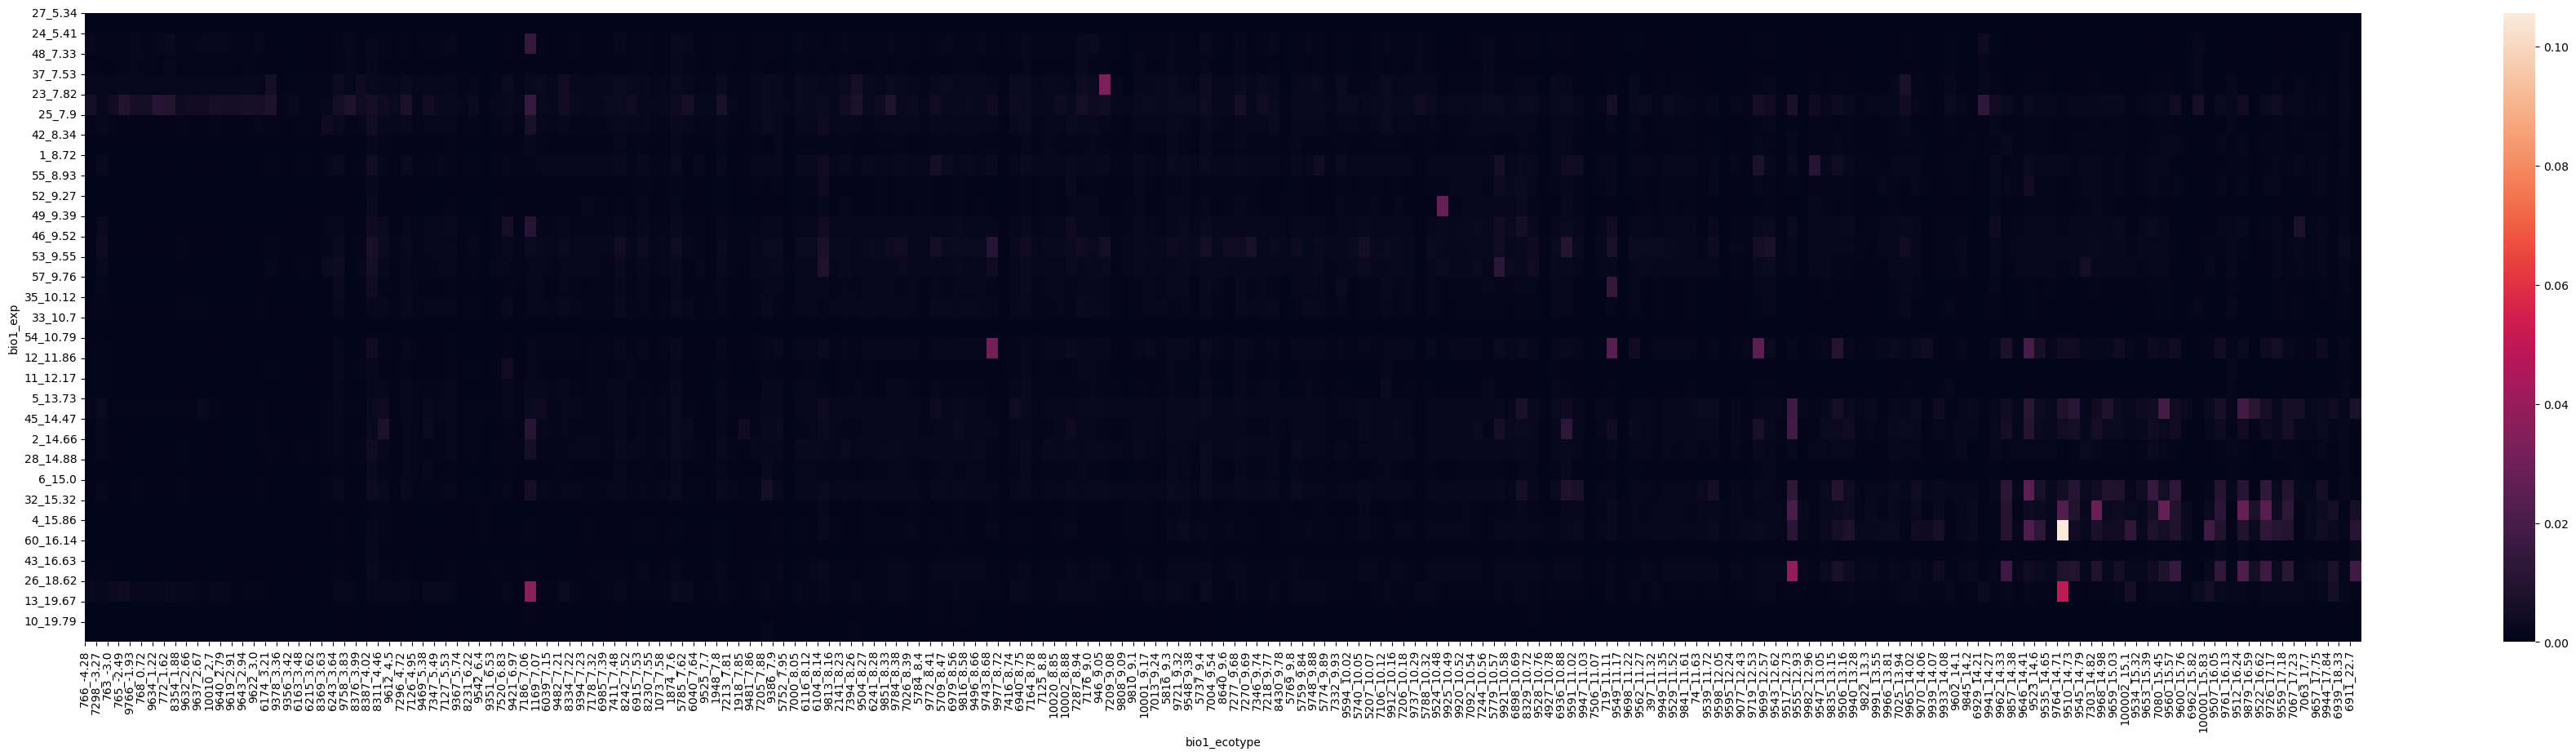

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming bioexp_vs_bioecotype is your DataFrame
plt.figure(figsize=(45, 10))  # Adjust the figure size as needed

# Create the heatmap
ax = sns.heatmap(bioexp_vs_bioecotype)

# Set x-tick labels with rotation for better visibility
ax.set_xticks(range(len(bioexp_vs_bioecotype.columns)))  # Set ticks for each column
ax.set_xticklabels(bioexp_vs_bioecotype.columns, rotation=90)  # Rotate labels for readability

# Optional: Set y-tick labels if needed
ax.set_yticks(range(len(bioexp_vs_bioecotype.index)))
ax.set_yticklabels(bioexp_vs_bioecotype.index)

# Show the plot
plt.show()


In [48]:
pseudo_prs_exon3 = pd.read_csv('pseudo_prs_exon3_grenenet.csv')

In [49]:
pseudo_prs_exon3.dtypes

index          int64
0              int64
ecotypeid      int64
bio1         float64
dtype: object

In [50]:
pseudo_prs_exon3['bio1_ecotype'] = pseudo_prs_exon3['ecotypeid'].astype(str) + '_' +  pseudo_prs_exon3['bio1'].round(2).astype(str)

In [51]:
pseudo_prs_exon3 = pseudo_prs_exon3.drop('index',axis=1)

In [52]:
pseudo_prs_exon3.columns = ['psuedo_prs', 'ecotypeid', 'bio1', 'bio1_ecotype']

In [53]:
pseudo_prs_exon3[['psuedo_prs', 'bio1_ecotype']]

,psuedo_prs,bio1_ecotype
0,16,100001_15.83
1,0,100002_15.1
2,0,10002_8.88
3,2,10006_11.32
4,6,10011_7.7
...,...,...
224,2,9947_11.03
225,2,9965_14.02
226,0,9966_13.81
227,14,9978_8.72


In [54]:
bioexp_vs_bioecotype.T

bio1_exp,27_5.34,24_5.41,48_7.33,37_7.53,23_7.82,25_7.9,42_8.34,1_8.72,55_8.93,52_9.27,...,2_14.66,28_14.88,6_15.0,32_15.32,4_15.86,60_16.14,43_16.63,26_18.62,13_19.67,10_19.79
bio1_ecotype,,,,,,,,,,,,,,,,,,,,,
766_-4.28,-0.004198,-0.002497,-0.002983,-0.002488,0.001235,-0.003261,-0.004080,-0.003680,-0.004159,-0.004150,...,-0.003793,-0.003886,-0.003408,-0.004007,-0.004014,-0.004106,-0.003735,-0.001943,-0.004153,-0.004099
7298_-3.27,-0.004211,-0.003257,-0.003665,-0.002483,-0.002397,-0.002530,-0.003478,-0.001903,-0.003489,-0.003689,...,-0.002330,-0.003433,-0.002324,-0.003831,-0.003493,-0.003684,-0.003217,-0.002874,-0.003504,-0.003886
763_-3.0,-0.004110,-0.002982,-0.003333,-0.002790,0.000683,-0.003241,-0.003893,-0.003743,-0.004029,-0.004045,...,-0.003599,-0.003641,-0.003564,-0.003917,-0.003878,-0.004030,-0.003727,-0.000850,-0.004053,-0.003998
765_-2.49,-0.003758,-0.002785,-0.002806,-0.001978,0.005931,-0.003157,-0.003541,-0.003355,-0.003685,-0.003687,...,-0.003243,-0.003398,-0.003152,-0.003464,-0.003464,-0.003540,-0.003459,0.000439,-0.003723,-0.003648
9766_-1.93,-0.004748,-0.002744,-0.003429,-0.002818,0.000881,-0.004060,-0.004648,-0.004344,-0.004698,-0.004700,...,-0.004364,-0.004343,-0.003899,-0.004647,-0.004559,-0.004656,-0.004482,-0.003242,-0.004683,-0.004636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7063_17.7,-0.001949,-0.001780,-0.001632,-0.001518,-0.001159,-0.001543,-0.001088,-0.001190,-0.001414,-0.001530,...,-0.001257,-0.001735,-0.000700,0.000298,0.000450,-0.001327,-0.000108,-0.000819,-0.001838,-0.001875
9657_17.75,-0.002985,-0.002482,-0.002649,-0.001943,-0.001384,-0.002263,-0.002123,-0.001620,-0.001491,-0.002343,...,-0.001518,-0.002398,0.002683,0.000326,0.001950,-0.002227,0.000077,-0.001652,-0.002720,-0.002833
9944_17.84,-0.005360,-0.005360,-0.005322,-0.005285,-0.005039,-0.005266,-0.004972,-0.005034,-0.005020,-0.005262,...,-0.005123,-0.005311,-0.004567,0.000085,-0.002208,-0.005137,0.002069,0.000394,-0.005330,-0.005360


In [55]:
pseudo_prs_exon3[['psuedo_prs', 'bio1_ecotype']]

,psuedo_prs,bio1_ecotype
0,16,100001_15.83
1,0,100002_15.1
2,0,10002_8.88
3,2,10006_11.32
4,6,10011_7.7
...,...,...
224,2,9947_11.03
225,2,9965_14.02
226,0,9966_13.81
227,14,9978_8.72


In [56]:
merged_df = pseudo_prs_exon3[['psuedo_prs', 'bio1_ecotype']].set_index('bio1_ecotype').join(bioexp_vs_bioecotype.T)

In [57]:
merged_df

,psuedo_prs,27_5.34,24_5.41,48_7.33,37_7.53,23_7.82,25_7.9,42_8.34,1_8.72,55_8.93,...,2_14.66,28_14.88,6_15.0,32_15.32,4_15.86,60_16.14,43_16.63,26_18.62,13_19.67,10_19.79
bio1_ecotype,,,,,,,,,,,,,,,,,,,,,
100001_15.83,16,-0.001436,-0.001332,-0.001378,-0.001277,-0.001036,-0.001247,-0.001061,-0.000892,-0.000969,...,-0.001196,-0.001336,-0.000324,0.000988,0.015948,-0.000943,0.000571,0.003482,-0.001338,-0.001435
100002_15.1,0,-0.001433,-0.001313,-0.001347,-0.001203,-0.000963,-0.001227,-0.001005,-0.000902,-0.000965,...,-0.001111,-0.001276,-0.000263,0.001246,0.011598,-0.000890,0.000185,0.003888,-0.001352,-0.001377
10002_8.88,0,-0.006576,-0.005725,-0.006031,-0.005291,-0.004183,-0.003908,-0.005570,-0.004432,-0.003752,...,-0.004310,-0.005596,-0.004378,-0.005574,-0.005194,-0.005982,-0.004726,-0.005257,-0.005967,-0.006391
10006_11.32,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10011_7.7,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9947_11.03,2,-0.002648,-0.002648,-0.002602,-0.002598,-0.002508,-0.002604,-0.002494,-0.002542,-0.002530,...,-0.002424,-0.002625,-0.002411,-0.001937,-0.001944,-0.002580,-0.002154,-0.002330,-0.002648,-0.002648
9965_14.02,2,-0.009359,-0.008870,-0.008984,-0.008442,-0.007859,-0.008639,-0.008477,-0.008014,-0.008025,...,-0.007905,-0.008758,-0.005453,-0.006555,-0.005484,-0.008729,-0.006958,-0.007883,-0.009141,-0.009224
9966_13.81,0,-0.005536,-0.004897,-0.004920,-0.004264,-0.003732,-0.004458,-0.004413,-0.003986,-0.004356,...,-0.003648,-0.004681,-0.002475,-0.003368,-0.002845,-0.004908,-0.003649,-0.004338,-0.005243,-0.005331


In [58]:
merged_df = merged_df.dropna()

In [59]:
merged_df

,psuedo_prs,27_5.34,24_5.41,48_7.33,37_7.53,23_7.82,25_7.9,42_8.34,1_8.72,55_8.93,...,2_14.66,28_14.88,6_15.0,32_15.32,4_15.86,60_16.14,43_16.63,26_18.62,13_19.67,10_19.79
bio1_ecotype,,,,,,,,,,,,,,,,,,,,,
100001_15.83,16,-0.001436,-0.001332,-0.001378,-0.001277,-1.036489e-03,-0.001247,-0.001061,-0.000892,-0.000969,...,-0.001196,-0.001336,-0.000324,0.000988,0.015948,-0.000943,0.000571,0.003482,-0.001338,-0.001435
100002_15.1,0,-0.001433,-0.001313,-0.001347,-0.001203,-9.634457e-04,-0.001227,-0.001005,-0.000902,-0.000965,...,-0.001111,-0.001276,-0.000263,0.001246,0.011598,-0.000890,0.000185,0.003888,-0.001352,-0.001377
10002_8.88,0,-0.006576,-0.005725,-0.006031,-0.005291,-4.183166e-03,-0.003908,-0.005570,-0.004432,-0.003752,...,-0.004310,-0.005596,-0.004378,-0.005574,-0.005194,-0.005982,-0.004726,-0.005257,-0.005967,-0.006391
5784_8.4,0,-0.003232,-0.002837,-0.002852,-0.002280,-2.016803e-03,-0.002460,-0.002669,-0.001820,-0.002327,...,-0.002055,-0.002834,-0.002392,-0.002694,-0.002526,-0.002676,-0.002526,-0.002523,-0.003144,-0.003184
6040_7.64,0,-0.003667,-0.003169,-0.002950,-0.002791,-2.035480e-03,-0.002785,-0.003097,-0.002049,-0.003008,...,-0.002812,-0.003253,-0.002662,-0.003350,-0.003244,-0.003418,-0.003098,-0.003225,-0.003538,-0.003600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9941_14.27,0,-0.004260,-0.003345,-0.003507,-0.003135,-6.417959e-07,-0.002559,-0.003347,-0.001839,-0.001941,...,-0.002305,-0.003084,-0.002210,-0.003244,-0.003058,-0.003675,-0.002787,-0.003235,-0.003762,-0.004017
9944_17.84,14,-0.005360,-0.005360,-0.005322,-0.005285,-5.038948e-03,-0.005266,-0.004972,-0.005034,-0.005020,...,-0.005123,-0.005311,-0.004567,0.000085,-0.002208,-0.005137,0.002069,0.000394,-0.005330,-0.005360
9947_11.03,2,-0.002648,-0.002648,-0.002602,-0.002598,-2.508293e-03,-0.002604,-0.002494,-0.002542,-0.002530,...,-0.002424,-0.002625,-0.002411,-0.001937,-0.001944,-0.002580,-0.002154,-0.002330,-0.002648,-0.002648


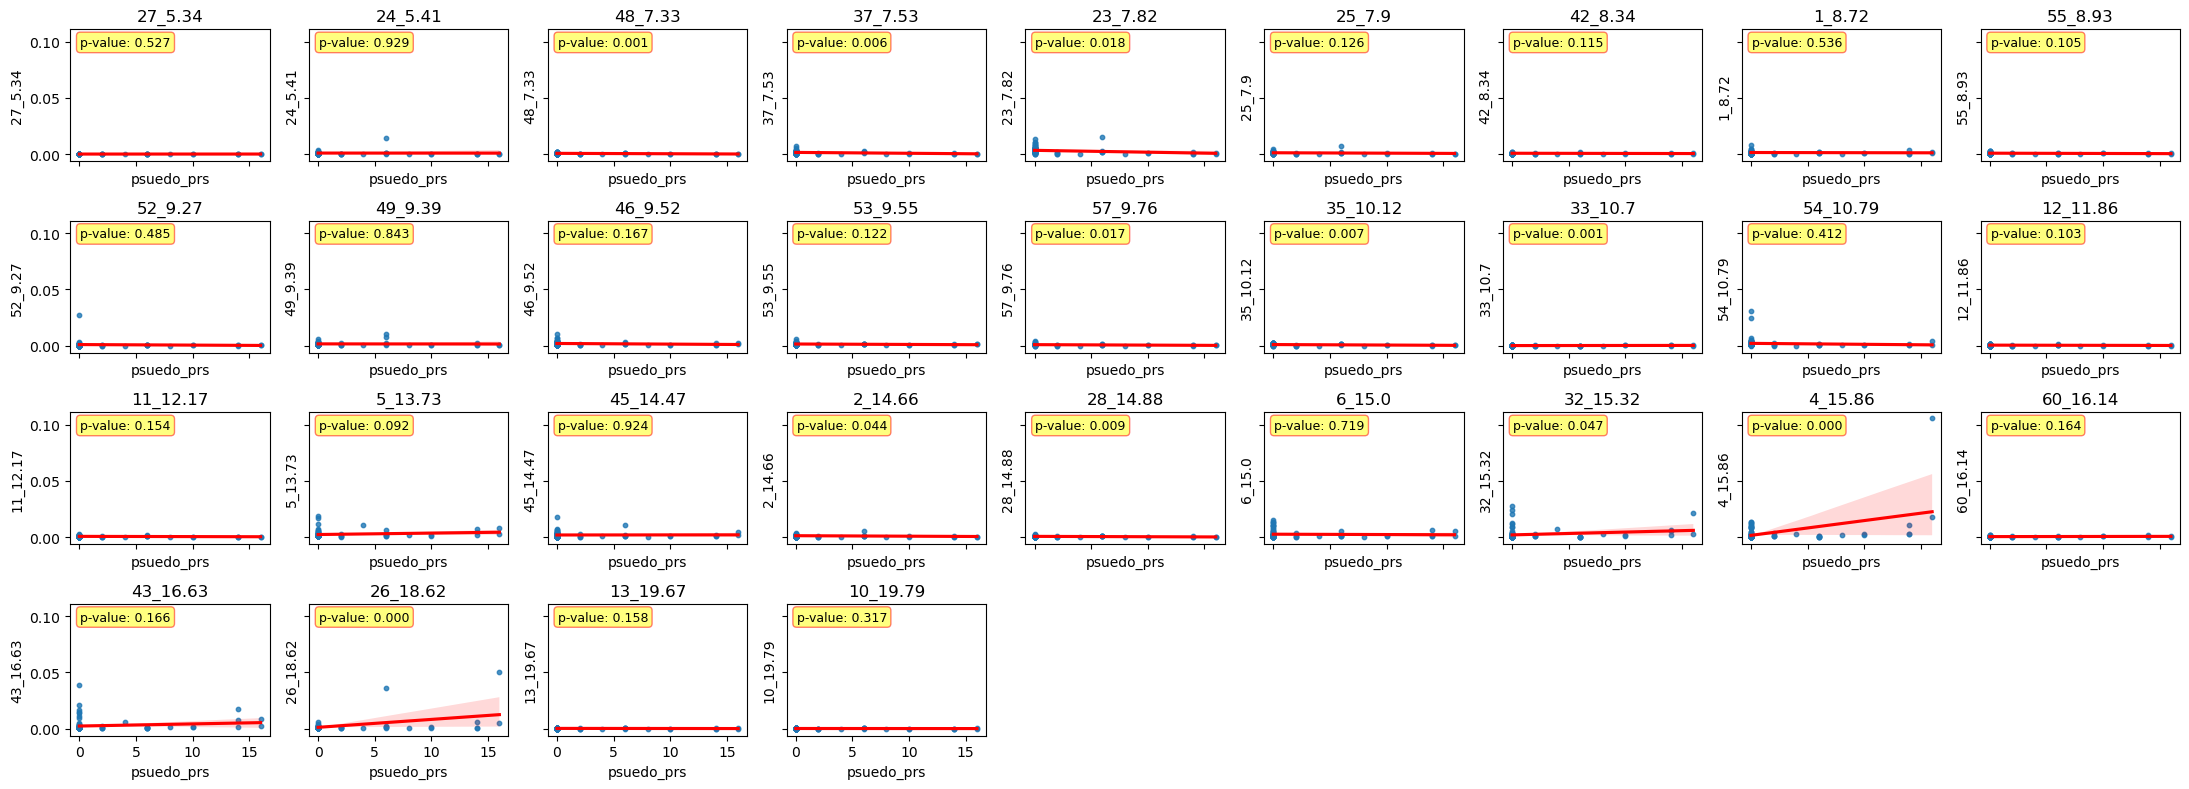

In [296]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np

# Set up the figure and axes
fig, axes = plt.subplots(nrows=4, ncols=9, figsize=(22, 8), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten the axes array for easier iteration

# Loop through the columns you want to plot against 'pseudo_prs'
for i, col in enumerate(merged_df.columns[1:]):
    # Prepare data for regression
    x = merged_df['psuedo_prs'].values  # Predictor
    y = merged_df[col].values  # Response
    x = sm.add_constant(x)  # Adds a constant term to the predictor
    
    # Perform regression
    model = sm.OLS(y, x, missing='drop')  # OLS regression, excluding NaNs
    results = model.fit()
    
    # Extract slope and p-value
    slope = results.params[1]
    p_value = results.pvalues[1]
    
    # Create a regplot on the appropriate subplot
    sns.regplot(data=merged_df, x='psuedo_prs', y=col, ax=axes[i], scatter_kws={'s': 10}, line_kws={'color': 'red'})
    
    # Annotate the plot with slope and p-value
    annotation = f'p-value: {p_value:.3f}'
    axes[i].annotate(annotation, xy=(0.05, 0.95), xycoords='axes fraction', ha='left', va='top', fontsize=9, bbox=dict(boxstyle="round,pad=0.3", edgecolor='red', facecolor='yellow', alpha=0.5))
    
    # Set the title to the column name for clarity
    axes[i].set_title(f'{col}')

# Adjust layout to prevent overlap
plt.tight_layout()

# Hide any unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

# Show the plot
plt.show()


In [299]:
pseudo_prs_exon3

,psuedo_prs,ecotypeid,bio1,bio1_ecotype
0,16,100001,15.829166,100001_15.83
1,0,100002,15.100000,100002_15.1
2,0,10002,8.879167,10002_8.88
3,2,10006,11.320833,10006_11.32
4,6,10011,7.704167,10011_7.7
...,...,...,...,...
224,2,9947,11.029166,9947_11.03
225,2,9965,14.025000,9965_14.02
226,0,9966,13.812500,9966_13.81
227,14,9978,8.716667,9978_8.72


In [302]:
result

,plot,site,generation,ecotype,freq,bio1_ecotype,bio1_exp
0,1,1,1,10002,0.001811,8.88,8.72
1,2,1,1,10002,0.002972,8.88,8.72
2,3,1,1,10002,0.002207,8.88,8.72
3,4,1,1,10002,0.002224,8.88,8.72
4,5,1,1,10002,0.003074,8.88,8.72
...,...,...,...,...,...,...,...
172090,8,60,1,9992,0.000657,9.89,16.14
172091,9,60,1,9992,0.000834,9.89,16.14
172092,10,60,1,9992,0.037258,9.89,16.14
172093,11,60,1,9992,0.000362,9.89,16.14


In [60]:
result_w_prs = result.merge(pseudo_prs_exon3[['ecotypeid', 'psuedo_prs']], left_on = 'ecotype', right_on = 'ecotypeid')

In [61]:
result_w_prs

,plot,site,generation,ecotype,freq,bio1_ecotype,bio1_exp,ecotypeid,psuedo_prs
0,1,1,1,10002,-0.004779,8.88,8.72,10002,0
1,2,1,1,10002,-0.003618,8.88,8.72,10002,0
2,3,1,1,10002,-0.004384,8.88,8.72,10002,0
3,4,1,1,10002,-0.004367,8.88,8.72,10002,0
4,5,1,1,10002,-0.003516,8.88,8.72,10002,0
...,...,...,...,...,...,...,...,...,...
170600,8,60,1,9940,-0.000827,13.28,16.14,9940,10
170601,9,60,1,9940,-0.000107,13.28,16.14,9940,10
170602,10,60,1,9940,-0.000898,13.28,16.14,9940,10
170603,11,60,1,9940,-0.000992,13.28,16.14,9940,10


In [65]:
import statsmodels.api as sm


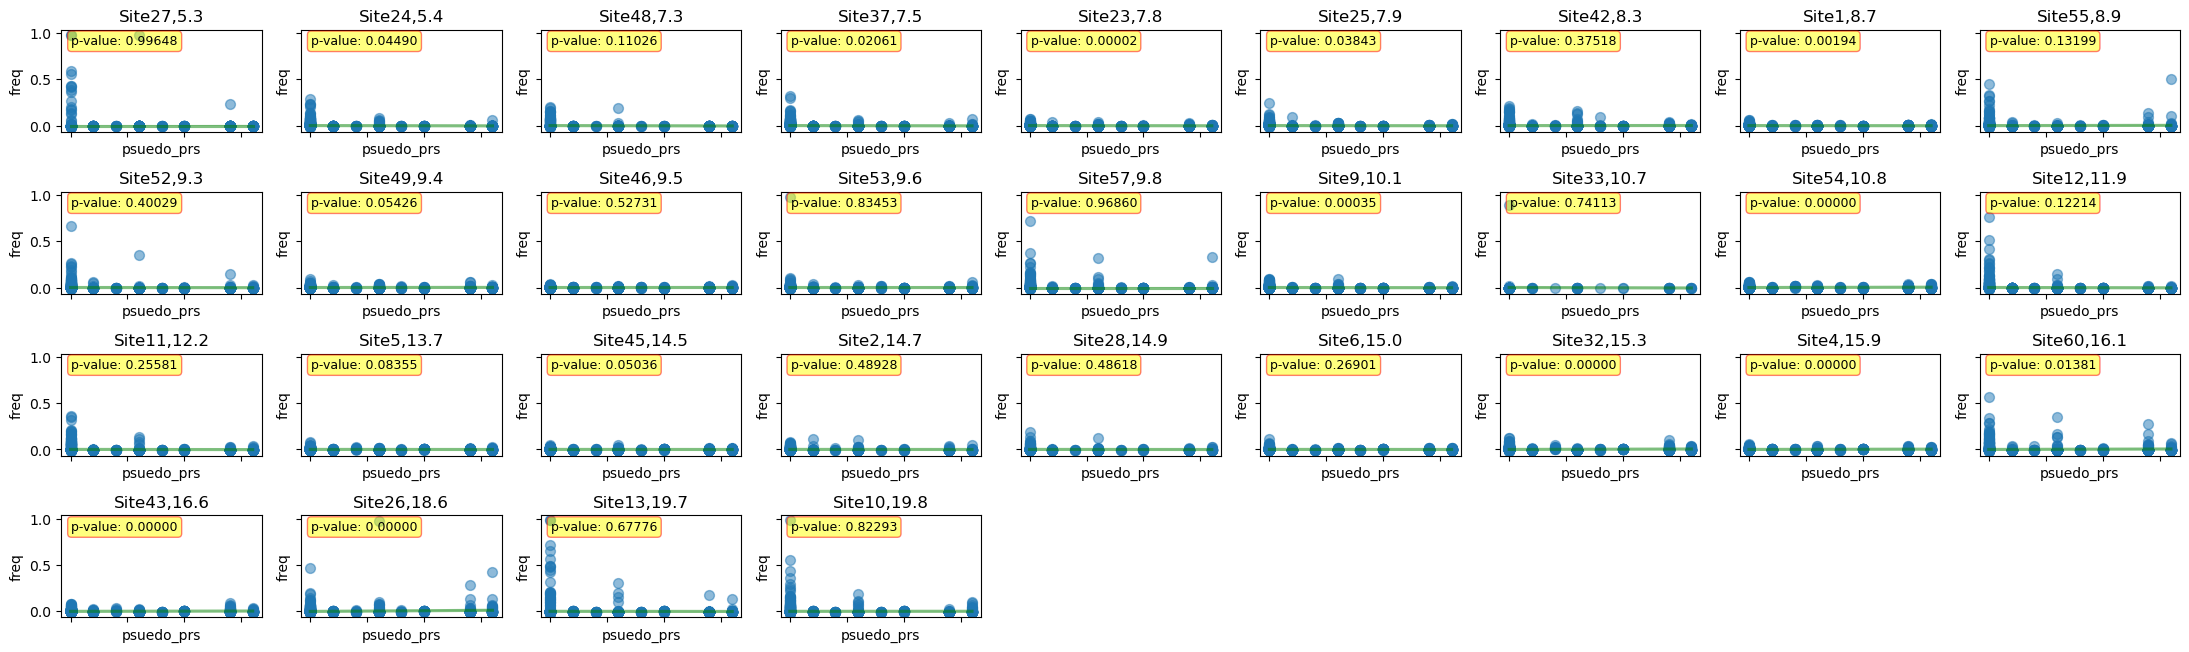

In [66]:
result_w_prsgen3 = result_w_prs[result_w_prs['generation']==1]

# Assuming result_w_prsgen3 is your DataFrame
# Step 1: Aggregate bio1_exp for each site (using mean in this example)
site_bio1_exp = result_w_prsgen3.groupby('site')['bio1_exp'].mean()

# Step 2: Sort the sites by bio1_exp
sorted_sites = site_bio1_exp.sort_values().index.tolist()

# Step 3: Determine layout for subplots
num_sites = len(sorted_sites)
num_cols = 3  # Adjust the number of columns as needed
num_rows = (num_sites + num_cols - 1) // num_cols  # Ensures enough rows

# Create a figure with subplots
fig, axes = plt.subplots(nrows=5, ncols=9, figsize=(22, 8), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten the array of axes

# Loop through each sorted site and plot
for i, site in enumerate(sorted_sites):
    # Filter data for the current site
    data_filtered = result_w_prsgen3[result_w_prsgen3['site'] == site]

    # Create a scatter plot on the appropriate subplot
    sns.regplot(data=data_filtered, x='psuedo_prs', y='freq', ax=axes[i], 
                scatter_kws={"alpha": 0.5, "s": 50},  # Set alpha to 0.5 for transparency, adjust size 's' as needed
                line_kws={"color": "green","alpha": 0.5})

    # Fit linear regression model
    X = sm.add_constant(data_filtered['psuedo_prs'])  # adding a constant
    model = sm.OLS(data_filtered['freq'], X).fit()
    p_value = model.pvalues[1]  # p-value for the slope

    # Get the bio1_exp value for the title
    bio1_exp_value = site_bio1_exp.loc[site]

    # Set title with site, bio1_exp value, and p-value
    axes[i].set_title(f'Site{site},{bio1_exp_value:.1f}')
    annotation = f'p-value: {p_value:.5f}'
    axes[i].annotate(annotation, xy=(0.05, 0.95), xycoords='axes fraction', ha='left', va='top', fontsize=9, bbox=dict(boxstyle="round,pad=0.3", edgecolor='red', facecolor='yellow', alpha=0.5))
# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Adjust layout and show plot
plt.tight_layout()
plt.show()


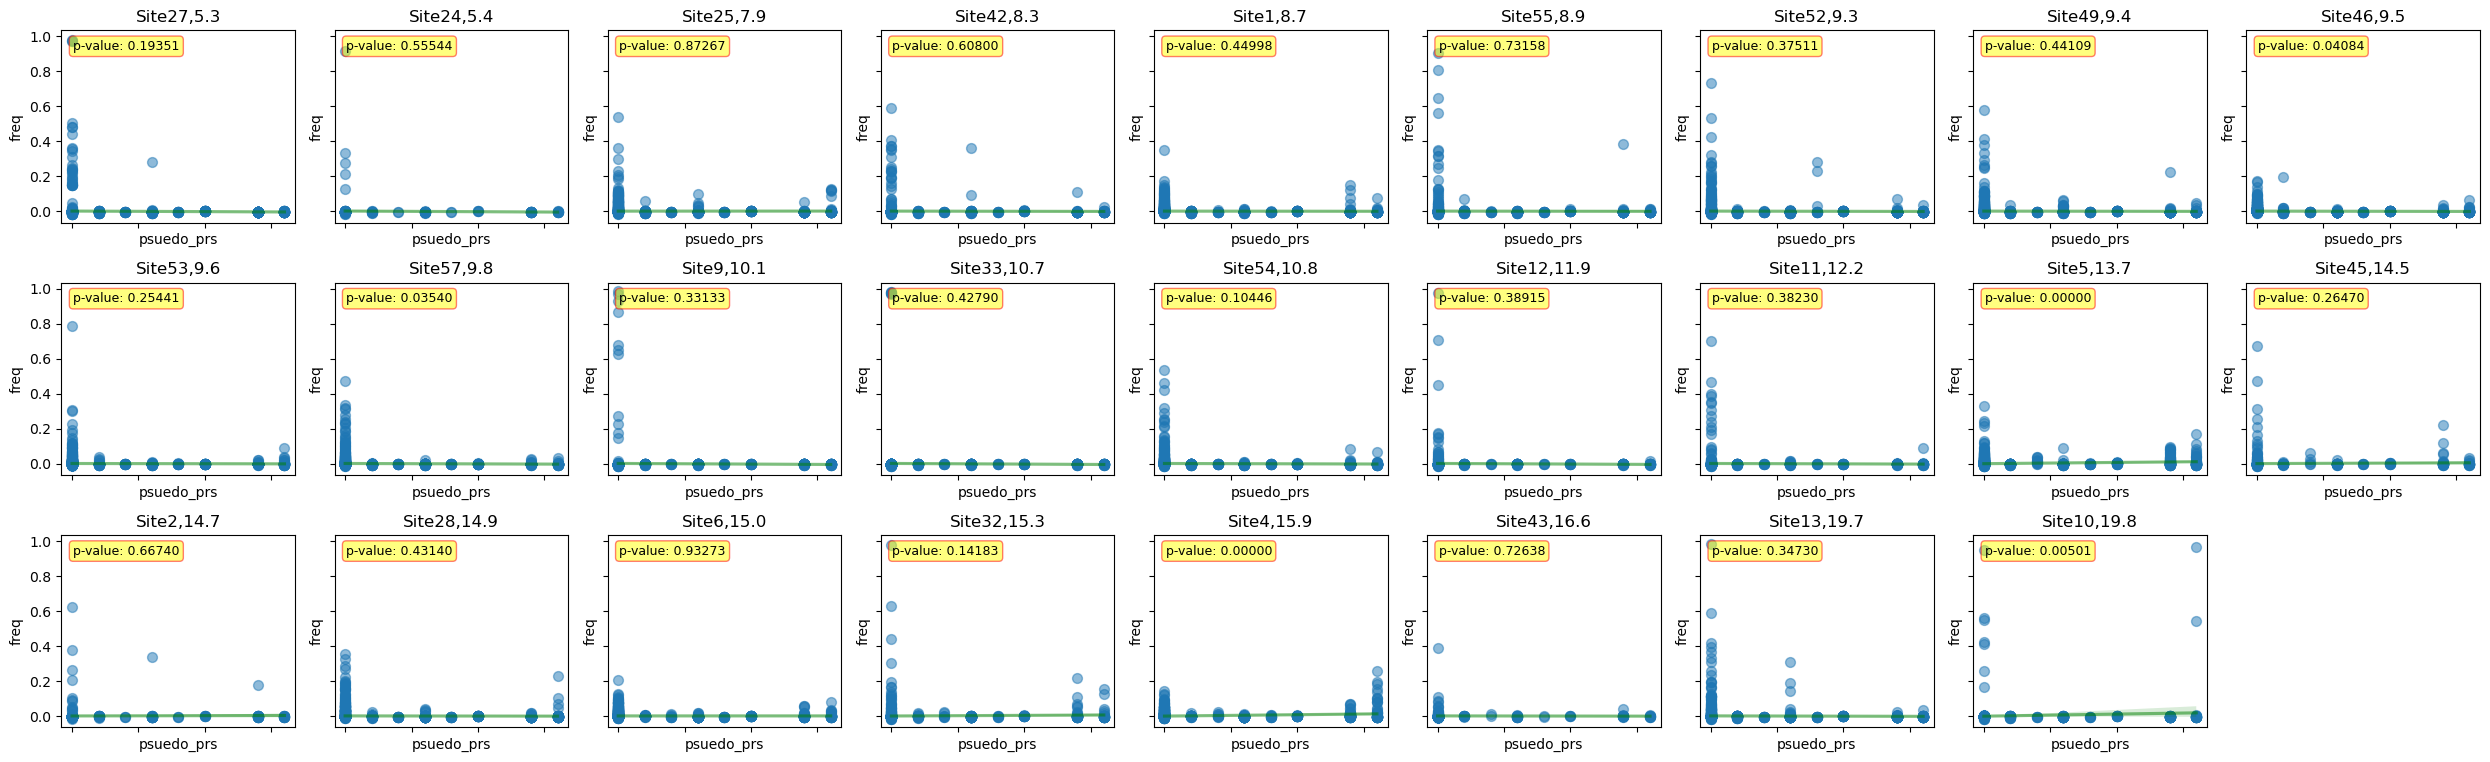

In [69]:
result_w_prsgen3 = result_w_prs[result_w_prs['generation']==2]

# Assuming result_w_prsgen3 is your DataFrame
# Step 1: Aggregate bio1_exp for each site (using mean in this example)
site_bio1_exp = result_w_prsgen3.groupby('site')['bio1_exp'].mean()

# Step 2: Sort the sites by bio1_exp
sorted_sites = site_bio1_exp.sort_values().index.tolist()

# Step 3: Determine layout for subplots
num_sites = len(sorted_sites)
num_cols = 3  # Adjust the number of columns as needed
num_rows = (num_sites + num_cols - 1) // num_cols  # Ensures enough rows

# Create a figure with subplots
fig, axes = plt.subplots(nrows=4, ncols=9, figsize=(25, 10), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten the array of axes

# Loop through each sorted site and plot
for i, site in enumerate(sorted_sites):
    # Filter data for the current site
    data_filtered = result_w_prsgen3[result_w_prsgen3['site'] == site]

    # Create a scatter plot on the appropriate subplot
    sns.regplot(data=data_filtered, x='psuedo_prs', y='freq', ax=axes[i], 
                scatter_kws={"alpha": 0.5, "s": 50},  # Set alpha to 0.5 for transparency, adjust size 's' as needed
                line_kws={"color": "green","alpha": 0.5})

    # Fit linear regression model
    X = sm.add_constant(data_filtered['psuedo_prs'])  # adding a constant
    model = sm.OLS(data_filtered['freq'], X).fit()
    p_value = model.pvalues[1]  # p-value for the slope

    # Get the bio1_exp value for the title
    bio1_exp_value = site_bio1_exp.loc[site]

    # Set title with site, bio1_exp value, and p-value
    axes[i].set_title(f'Site{site},{bio1_exp_value:.1f}')
    annotation = f'p-value: {p_value:.5f}'
    axes[i].annotate(annotation, xy=(0.05, 0.95), xycoords='axes fraction', ha='left', va='top', fontsize=9, bbox=dict(boxstyle="round,pad=0.3", edgecolor='red', facecolor='yellow', alpha=0.5))
# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Adjust layout and show plot
plt.tight_layout()
plt.show()


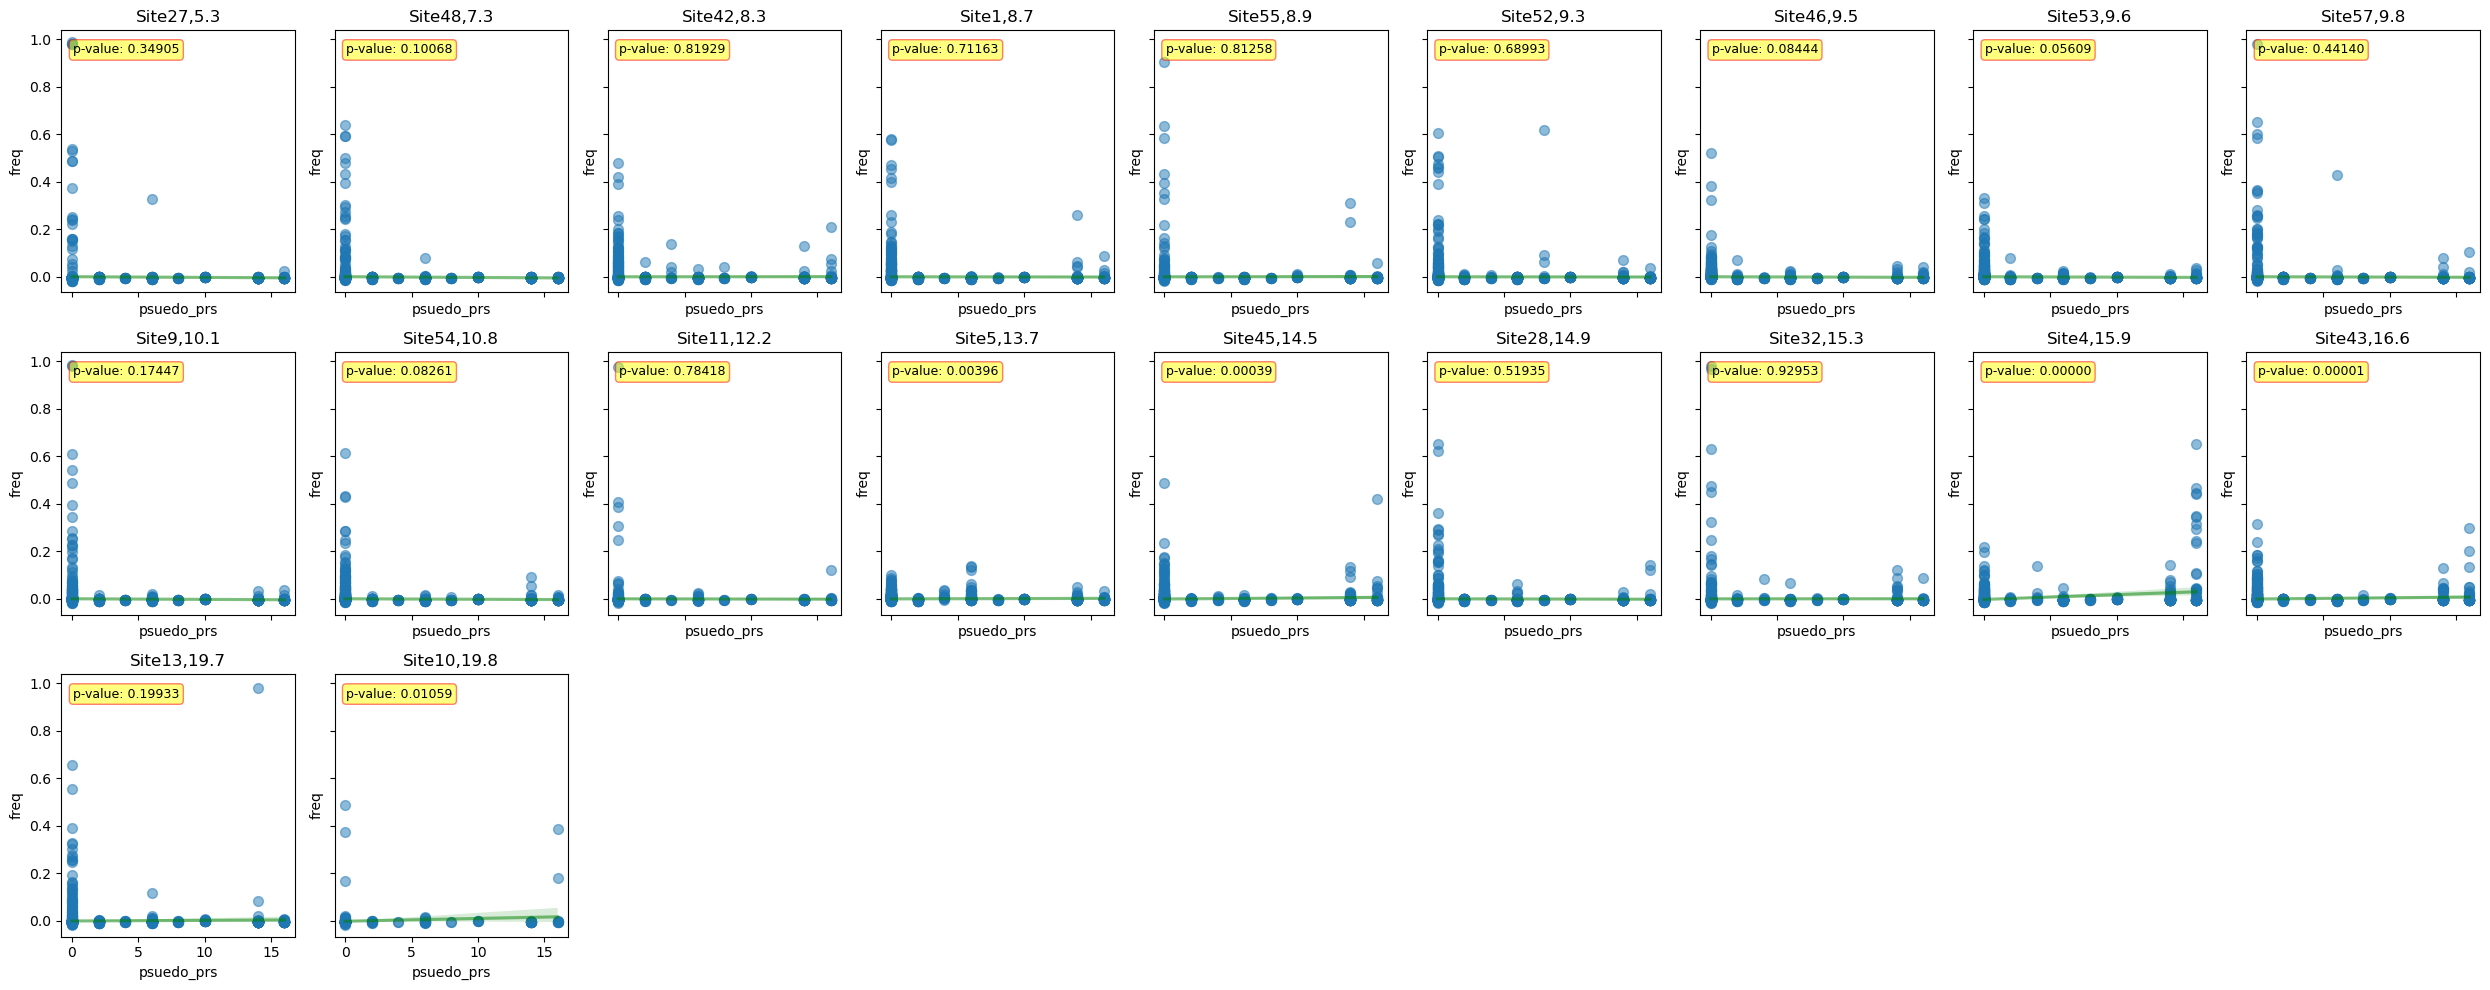

In [70]:
result_w_prsgen3 = result_w_prs[result_w_prs['generation']==3]

# Assuming result_w_prsgen3 is your DataFrame
# Step 1: Aggregate bio1_exp for each site (using mean in this example)
site_bio1_exp = result_w_prsgen3.groupby('site')['bio1_exp'].mean()

# Step 2: Sort the sites by bio1_exp
sorted_sites = site_bio1_exp.sort_values().index.tolist()

# Step 3: Determine layout for subplots
num_sites = len(sorted_sites)
num_cols = 3  # Adjust the number of columns as needed
num_rows = (num_sites + num_cols - 1) // num_cols  # Ensures enough rows

# Create a figure with subplots
fig, axes = plt.subplots(nrows=3, ncols=9, figsize=(25, 10), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten the array of axes

# Loop through each sorted site and plot
for i, site in enumerate(sorted_sites):
    # Filter data for the current site
    data_filtered = result_w_prsgen3[result_w_prsgen3['site'] == site]

    # Create a scatter plot on the appropriate subplot
    sns.regplot(data=data_filtered, x='psuedo_prs', y='freq', ax=axes[i], 
                scatter_kws={"alpha": 0.5, "s": 50},  # Set alpha to 0.5 for transparency, adjust size 's' as needed
                line_kws={"color": "green","alpha": 0.5})

    # Fit linear regression model
    X = sm.add_constant(data_filtered['psuedo_prs'])  # adding a constant
    model = sm.OLS(data_filtered['freq'], X).fit()
    p_value = model.pvalues[1]  # p-value for the slope

    # Get the bio1_exp value for the title
    bio1_exp_value = site_bio1_exp.loc[site]

    # Set title with site, bio1_exp value, and p-value
    axes[i].set_title(f'Site{site},{bio1_exp_value:.1f}')
    annotation = f'p-value: {p_value:.5f}'
    axes[i].annotate(annotation, xy=(0.05, 0.95), xycoords='axes fraction', ha='left', va='top', fontsize=9, bbox=dict(boxstyle="round,pad=0.3", edgecolor='red', facecolor='yellow', alpha=0.5))
# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Adjust layout and show plot
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np

# Set up the figure and axes
fig, axes = plt.subplots(nrows=4, ncols=9, figsize=(22, 8), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten the axes array for easier iteration

# Loop through the columns you want to plot against 'pseudo_prs'
for i, col in result_w_prsgen3['site'].unique()):
    # Prepare data for regression
    x = merged_df['psuedo_prs'].values  # Predictor
    y = merged_df[col].values  # Response
    x = sm.add_constant(x)  # Adds a constant term to the predictor
    
    # Perform regression
    model = sm.OLS(y, x, missing='drop')  # OLS regression, excluding NaNs
    results = model.fit()
    
    # Extract slope and p-value
    slope = results.params[1]
    p_value = results.pvalues[1]
    
    # Create a regplot on the appropriate subplot
    sns.regplot(data=merged_df, x='psuedo_prs', y=col, ax=axes[i], scatter_kws={'s': 10}, line_kws={'color': 'red'})
    
    # Annotate the plot with slope and p-value
    annotation = f'p-value: {p_value:.3f}'
    axes[i].annotate(annotation, xy=(0.05, 0.95), xycoords='axes fraction', ha='left', va='top', fontsize=9, bbox=dict(boxstyle="round,pad=0.3", edgecolor='red', facecolor='yellow', alpha=0.5))
    
    # Set the title to the column name for clarity
    axes[i].set_title(f'{col}')

# Adjust layout to prevent overlap
plt.tight_layout()

# Hide any unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

# Show the plot
plt.show()